In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import ast

warnings.filterwarnings('ignore')

print("TensorFlow Version:", tf.__version__)
print("Pandas Version:", pd.__version__)
print("NumPy Version:", np.__version__)
print("All libraries imported successfully!")


TensorFlow Version: 2.19.0
Pandas Version: 2.2.2
NumPy Version: 2.0.2
All libraries imported successfully!


In [ ]:
print("="*60)
print("LOADING DATASET")
print("="*60)

from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]

try:
    df = pd.read_csv(filename)
    print("\nDataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Columns: {len(df.columns)}")

    print("\nFirst 5 rows:")
    print(df.head())

    print("\nColumn names:")
    print(df.columns.tolist())

    print("\nMissing values:")
    print(df.isnull().sum().sum())

    print("\nData types:")
    print(df.dtypes.value_counts())

    if any(col.lower() in ['label', 'class'] for col in df.columns):
        label_col = [col for col in df.columns if col.lower() in ['label', 'class']][0]
        print(f"\nLabel column found: '{label_col}'")
        print("Label distribution:")
        print(df[label_col].value_counts())
    else:
        print("\nNo standard label column found. Please specify the label column name.")

except Exception as e:
    print("Error:", e)


LOADING DATASET


Saving Final_Dataset_without_duplicate.csv to Final_Dataset_without_duplicate.csv

Dataset loaded successfully!
Shape: (21752, 77)
Columns: 77

First 5 rows:
                                md5                                      sha1  \
0  d5aa2b2506dd71b65307bb551a6a099d  62f4d55a1bb8396e493d7815dc44febed7161535   
1  8d1178cec97f96a9ede3efe2f30ef30e  ca40945a4e35d48794a5e13aacf16b8ae1caddeb   
2  c08d7afb7966f452cf5aa9283fe8880a  6f47b50480bea61ae4dfb75c12582990cc5ce770   
3  3554a3a99e7ffb57552aedcb2520f1d2  8c3d5b506a8d55f42f4c83ead3e4341255d1acfc   
4  5be9511d42136df49d9501680e84109f  0a7d0c68c591db2f197b2169d226bebe6e9bdabe   

  file_extension EntryPoint PEType                          MachineType  \
0            exe    0x108ec  PE32+                            AMD AMD64   
1            exe   0x25cf9c  PE32+                            AMD AMD64   
2            exe     0x2a7e   PE32  Intel 386 or later, and compatibles   
3            exe    0x64ca0  PE32+                     

In [ ]:
# Cell 3: Preprocess the Dataset (Static Features Only)
print("\n" + "="*60)
print("PREPROCESSING DATASET (STATIC FEATURES ONLY)")
print("="*60)

label_col = 'Class'
print(f"Using '{label_col}' as the label column")

if label_col and label_col in df.columns:
    y = df[label_col].values

    # List of dynamic features to drop
    dynamic_features = [
        'EntryPoint', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData',
        'ImageBase', 'text_VirtualAddress', 'text_PointerToRawData',
        'text_PointerToRelocations', 'text_PointerToLineNumbers',
        'rdata_VirtualAddress', 'rdata_PointerToRawData',
        'rdata_PointerToRelocations', 'rdata_PointerToLineNumbers',
        'init_sp_value', 'init_ip_value', 'init_cs_value', 'init_ss_value',
        'over_lay_number', 'oem_identifier', 'address_of_ne_header'
    ]

    # Always drop non-feature columns
    non_feature_cols = [label_col, 'Category', 'Family', 'md5', 'sha1']
    columns_to_drop = [col for col in dynamic_features + non_feature_cols if col in df.columns]

    print(f"\nDropping dynamic and non-feature columns: {columns_to_drop}")
    X_df = df.drop(columns=columns_to_drop)

    # Convert all columns to numeric
    print("\nConverting all columns to numeric types...")
    X_numeric = pd.DataFrame()
    for column in X_df.columns:
        if X_df[column].dtype == 'object':
            converted = pd.to_numeric(X_df[column], errors='coerce')
            if converted.isna().mean() < 0.3:
                X_numeric[column] = converted
                print(f"  '{column}': converted to numeric (float)")
            else:
                X_numeric[column] = pd.factorize(X_df[column])[0]
                print(f"  '{column}': encoded categorical ({len(np.unique(X_df[column]))} categories)")
        else:
            X_numeric[column] = X_df[column]

    X = X_numeric.values

    # Handle labels
    unique_labels = np.unique(y)
    print(f"\nUnique labels: {unique_labels}")
    if len(unique_labels) == 2:
        label_mapping = {'Benign': 0, 'Malware': 1}
        y = np.array([label_mapping[label] for label in y])
        print(f"Labels mapped: Benign -> 0, Malware -> 1")

    # Handle missing/infinite values
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    print(f"\nFeature shape: {X.shape}")
    print(f"Label shape: {y.shape}")
    print(f"Label distribution: {np.bincount(y.astype(int))}")

    # Split into benign and ransomware
    X_benign = X[y == 0]
    X_ransomware = X[y == 1]
    print(f"\nBenign samples: {len(X_benign)}")
    print(f"Ransomware samples: {len(X_ransomware)}")

    # Feature statistics
    print("\n" + "-"*40)
    print("PROCESSED FEATURE STATISTICS")
    print("-"*40)
    print(f"Number of features: {X.shape[1]}")
    print(f"Feature range: [{X.min():.4f}, {X.max():.4f}]")
    print(f"Feature mean: {X.mean():.4f}")
    print(f"Feature std: {X.std():.4f}")

else:
    print(f"\nError: Label column '{label_col}' not found in dataframe.")
    print("Available columns:", df.columns.tolist())



PREPROCESSING DATASET (STATIC FEATURES ONLY)
Using 'Class' as the label column

Dropping dynamic and non-feature columns: ['EntryPoint', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'text_VirtualAddress', 'text_PointerToRawData', 'text_PointerToRelocations', 'text_PointerToLineNumbers', 'rdata_VirtualAddress', 'rdata_PointerToRawData', 'rdata_PointerToRelocations', 'rdata_PointerToLineNumbers', 'init_sp_value', 'init_ip_value', 'init_cs_value', 'init_ss_value', 'over_lay_number', 'oem_identifier', 'address_of_ne_header', 'Class', 'Category', 'Family', 'md5', 'sha1']

Converting all columns to numeric types...
  'file_extension': encoded categorical (1 categories)
  'PEType': encoded categorical (3 categories)
  'MachineType': encoded categorical (3 categories)
  'magic_number': encoded categorical (2 categories)
  'bytes_on_last_page': encoded categorical (70 categories)
  'pages_in_file': encoded categorical (71 categories)
  'relocations': encoded categorical (49 

In [ ]:
# Cell 4: Split Data - Use Only Benign for Training
print("\n" + "="*60)
print("PREPARING TRAINING AND TEST SETS")
print("="*60)

from sklearn.preprocessing import StandardScaler

if label_col:

    print("\nScaling features using StandardScaler for better autoencoder training...")

    # ------------------------------------------
    # FIT SCALER ON BENIGN DATA ONLY (IMPORTANT)
    # ------------------------------------------
    scaler = StandardScaler()
    X_benign_scaled = scaler.fit_transform(X_benign)
    X_ransomware_scaled = scaler.transform(X_ransomware)

    from sklearn.preprocessing import StandardScaler

    # scaler = StandardScaler()
    # X_benign_train = scaler.fit_transform(X_benign_scaled)
    # X_benign_val = scaler.transform(X_benign_val)
    # X_ransomware_scaled = scaler.transform(X_ransomware_scaled)

    # ------------------------------------------------------------
    # Proper splitting WITHOUT data leakage
    # ------------------------------------------------------------
    # 20% benign test
    X_benign_trainval, X_test_benign, y_benign_trainval, y_test_benign = train_test_split(
        X_benign_scaled,
        np.zeros(len(X_benign_scaled)),
        test_size=0.2,
        random_state=42
    )

    # from the remaining 80% → split Train(60%) + Val(20%)
    X_benign_train, X_benign_val = train_test_split(
        X_benign_trainval,
        test_size=0.25,  # 25% of 80% = 20%
        random_state=42
    )

    # Ransomware test set
    X_test_ransomware = X_ransomware_scaled
    y_test_ransomware = np.ones(len(X_test_ransomware))

    # Combine test sets
    X_test = np.vstack([X_test_benign, X_test_ransomware])
    y_test = np.concatenate([y_test_benign, y_test_ransomware])

    print(f"\nTraining set: {len(X_benign_train)} benign")
    print(f"Validation set: {len(X_benign_val)} benign")
    print(f"Test set: {len(X_test)} samples")
    print(f"  → {len(X_test_benign)} benign")
    print(f"  → {len(X_test_ransomware)} ransomware")

    # Save scaler
    import joblib
    joblib.dump(scaler, "feature_scaler.pkl")
    print("\n✓ StandardScaler saved as feature_scaler.pkl")



PREPARING TRAINING AND TEST SETS

Scaling features using StandardScaler for better autoencoder training...

Training set: 6525 benign
Validation set: 2175 benign
Test set: 13052 samples
  → 2176 benign
  → 10876 ransomware

✓ StandardScaler saved as feature_scaler.pkl


In [ ]:
# Cell 5: Define Contractive Autoencoder Class (DCAE without internal scaling)
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

class ContractiveAutoencoder:
    """
    Deep Contractive Autoencoder for Ransomware Detection
    """

    def __init__(self, input_dim, encoding_dim=32, lambda_param=0.001):
        """
        Initialize the Contractive Autoencoder

        Args:
            input_dim: Dimension of input features
            encoding_dim: Dimension of latent representation
            lambda_param: Contractive penalty coefficient
        """
        self.input_dim = input_dim
        self.encoding_dim = encoding_dim
        self.lambda_param = lambda_param
        self.model = None
        self.encoder = None
        self.decoder = None
        self.threshold = None
        self.training_model = None  # Separate model for training

    def build_model(self):
        """Build the contractive autoencoder architecture"""

        # Input layer
        input_layer = layers.Input(shape=(self.input_dim,))

        # Encoder
        encoded = layers.Dense(96, activation='relu',
                              kernel_initializer='he_normal',
                              name='encoder1')(input_layer)
        encoded = layers.BatchNormalization()(encoded)
        encoded = layers.Dropout(0.2)(encoded)

        encoded = layers.Dense(64, activation='relu',
                              kernel_initializer='he_normal',
                              name='encoder2')(encoded)
        encoded = layers.BatchNormalization()(encoded)
        encoded = layers.Dropout(0.2)(encoded)

        encoded_output = layers.Dense(self.encoding_dim, activation='relu',
                                     kernel_initializer='he_normal',
                                     name='encoded')(encoded)

        # Decoder
        decoded = layers.Dense(64, activation='relu',
                              kernel_initializer='he_normal',
                              name='decoder1')(encoded_output)
        decoded = layers.BatchNormalization()(decoded)
        decoded = layers.Dropout(0.2)(decoded)

        decoded = layers.Dense(96, activation='relu',
                              kernel_initializer='he_normal',
                              name='decoder2')(decoded)
        decoded = layers.BatchNormalization()(decoded)
        decoded = layers.Dropout(0.2)(decoded)

        decoded_output = layers.Dense(self.input_dim, activation='linear',
                                     name='decoded')(decoded)

        # Full autoencoder
        self.model = Model(inputs=input_layer, outputs=decoded_output)

        # Encoder model
        self.encoder = Model(inputs=input_layer, outputs=encoded_output)

        # Decoder model
        encoded_input = layers.Input(shape=(self.encoding_dim,))
        decoder_layer = self.model.layers[-7](encoded_input)
        decoder_layer = self.model.layers[-6](decoder_layer)
        decoder_layer = self.model.layers[-5](decoder_layer)
        decoder_layer = self.model.layers[-4](decoder_layer)
        decoder_layer = self.model.layers[-3](decoder_layer)
        decoder_layer = self.model.layers[-2](decoder_layer)
        decoder_output = self.model.layers[-1](decoder_layer)
        self.decoder = Model(inputs=encoded_input, outputs=decoder_output)

        # Build training model with contractive loss
        self._build_training_model()

        print("Model architecture built successfully!")
        print(f"Total parameters: {self.model.count_params():,}")
        return self.model

    def _build_training_model(self):
        """Build separate model for training with contractive loss"""
        input_layer = self.model.input
        encoded_output = self.encoder.output
        decoded_output = self.model.output

        self.training_model = Model(
            inputs=input_layer,
            outputs=[decoded_output, encoded_output]
        )

        self.training_model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss=[self._reconstruction_loss, self._contractive_penalty_loss],
            loss_weights=[1.0, self.lambda_param]
        )

    def _reconstruction_loss(self, y_true, y_pred):
        """Standard MSE reconstruction loss"""
        return tf.reduce_mean(tf.square(y_true - y_pred))

    def _contractive_penalty_loss(self, y_true, y_encoded):
        """Contractive penalty using Jacobian-free stability"""
        x = y_true
        noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=0.01)
        x_noisy = x + noise
        encoded_noisy = self.encoder(x_noisy)
        penalty = tf.reduce_mean(tf.square(y_encoded - encoded_noisy))
        return penalty

    def train(self, X_train, epochs=100, batch_size=32, validation_data=None):
        """
        Train the autoencoder on benign samples
        """
        # Assume data already scaled externally
        X_train_scaled = X_train
        if validation_data is not None:
            X_val_scaled = validation_data
            validation_data = (X_val_scaled, [X_val_scaled, X_val_scaled])

        if self.training_model is None:
            self.build_model()

        print(f"\nTraining on {len(X_train)} samples for {epochs} epochs...")

        early_stopping = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            min_delta=0.0001
        )

        reduce_lr = keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=0.00001
        )

        history = self.training_model.fit(
            X_train_scaled,
            [X_train_scaled, X_train_scaled],
            epochs=epochs,
            batch_size=batch_size,
            validation_data=validation_data,
            callbacks=[early_stopping, reduce_lr],
            shuffle=True,
            verbose=1
        )

        self._calculate_threshold(X_train_scaled)
        return history

    def _calculate_threshold(self, X_train):
        reconstructions = self.model.predict(X_train, verbose=0)
        errors = np.mean(np.square(X_train - reconstructions), axis=1)
        q75, q25 = np.percentile(errors, [75, 25])
        iqr = q75 - q25
        upper_bound = q75 + 3 * iqr
        filtered_errors = errors[errors <= upper_bound]

        if len(filtered_errors) > 0:
            self.threshold = np.percentile(filtered_errors, 99) * 1.1
        else:
            self.threshold = np.percentile(errors, 95) * 1.2

    def get_reconstruction_error(self, X):
        reconstructions = self.model.predict(X, verbose=0)
        errors = np.mean(np.square(X - reconstructions), axis=1)
        return np.log1p(errors)

    def predict(self, X_test, return_details=False):
        errors = self.get_reconstruction_error(X_test)
        log_threshold = np.log1p(self.threshold)
        predictions = (errors > log_threshold).astype(int)
        anomaly_scores = np.minimum(100, (errors / log_threshold) * 100)

        if return_details:
            return {
                'predictions': predictions,
                'anomaly_scores': anomaly_scores,
                'reconstruction_errors': errors,
                'threshold': log_threshold,
                'original_threshold': self.threshold
            }
        else:
            return predictions

    def evaluate_on_test(self, X_test, y_test):
        results = self.predict(X_test, return_details=True)
        from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

        print("\n" + "="*60)
        print("MODEL EVALUATION")
        print("="*60)

        cm = confusion_matrix(y_test, results['predictions'])
        print(f"\nConfusion Matrix: {cm}")
        print(classification_report(y_test, results['predictions'], target_names=['Benign', 'Ransomware']))
        auc = roc_auc_score(y_test, results['anomaly_scores'] / 100.0)
        print(f"ROC AUC Score: {auc:.4f}")

        return results

    def save_model(self, filepath):
        self.model.save(f"{filepath}_model.h5")
        self.encoder.save(f"{filepath}_encoder.h5")
        self.decoder.save(f"{filepath}_decoder.h5")
        np.save(f"{filepath}_threshold.npy", self.threshold)

    def load_model(self, filepath):
        self.model = keras.models.load_model(f"{filepath}_model.h5")
        self.encoder = keras.models.load_model(f"{filepath}_encoder.h5")
        self.decoder = keras.models.load_model(f"{filepath}_decoder.h5")
        self.threshold = np.load(f"{filepath}_threshold.npy")
        self.input_dim = self.model.input_shape[1]
        self.encoding_dim = self.encoder.output_shape[1]

print("ContractiveAutoencoder class defined successfully!")


ContractiveAutoencoder class defined successfully!


In [ ]:
#Cell 7: Initialize and Train the Model
print("\n" + "="*60)
print("TRAINING CONTRACTIVE AUTOENCODER")
print("="*60)

# Check if training data is available
if 'X_benign_train' in locals() and 'X_benign_val' in locals():
    # Show dataset statistics
    print(f"Input dimension: {X_benign_train.shape[1]}")
    print(f"Training samples: {X_benign_train.shape[0]}")
    print(f"Validation samples: {X_benign_val.shape[0]}")

    # Determine encoding dimension (based on input size)
    encoding_dim = min(64, X_benign_train.shape[1] // 4)
    print(f"Encoding dimension: {encoding_dim}")

    # Initialize CAE
    cae = ContractiveAutoencoder(
        input_dim=X_benign_train.shape[1],
        encoding_dim=encoding_dim,
        lambda_param=0.001   # Contractive penalty strength
    )

    # Train the model (only on benign samples)
    print("\nStarting training...")
    history = cae.train(
        X_benign_train,
        epochs=100,
        batch_size=64,
        validation_data=X_benign_val
    )

    print("\n✓ Training completed!")



TRAINING CONTRACTIVE AUTOENCODER
Input dimension: 52
Training samples: 6525
Validation samples: 2175
Encoding dimension: 13

Starting training...
Model architecture built successfully!
Total parameters: 25,601

Training on 6525 samples for 100 epochs...
Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - decoded_loss: 1.9553 - encoded_loss: 0.7513 - loss: 1.9560 - val_decoded_loss: 0.7840 - val_encoded_loss: 1.2049e-04 - val_loss: 0.7842 - learning_rate: 0.0010
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - decoded_loss: 1.0084 - encoded_loss: 0.6005 - loss: 1.0090 - val_decoded_loss: 0.6901 - val_encoded_loss: 1.5010e-04 - val_loss: 0.6903 - learning_rate: 0.0010
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - decoded_loss: 0.8826 - encoded_loss: 0.6199 - loss: 0.8832 - val_decoded_loss: 0.6483 - val_encoded_loss: 1.5499e-04 - val_loss: 0.6485 - learning_rate: 0.0010
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - decoded_loss: 0.7898 - encoded_loss: 0.5808 

In [ ]:
# # Cell 8: Visualize Training History
# print("\n" + "="*60)
# print("VISUALIZING TRAINING HISTORY")
# print("="*60)

# # Check if training history exists
# if 'history' in locals():
#     plt.figure(figsize=(14, 5))

#     # Plot loss
#     plt.subplot(1, 2, 1)
#     plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
#     plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
#     plt.xlabel('Epoch', fontsize=12)
#     plt.ylabel('Loss', fontsize=12)
#     plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
#     plt.legend(fontsize=10)
#     plt.grid(True, alpha=0.3)

#     # Plot individual losses if available
#     plt.subplot(1, 2, 2)

#     # Check what metrics are available
#     available_metrics = list(history.history.keys())
#     print(f"Available metrics in history: {available_metrics}")

#     # Print training summary
#     print("\nTraining Summary:")
#     print("-" * 40)
#     print(f"Final training loss: {history.history['loss'][-1]:.6f}")
#     print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")

#     if 'decoded_loss' in history.history:
#         print(f"Final reconstruction loss: {history.history['decoded_loss'][-1]:.6f}")
#         print(f"Final contractive penalty: {history.history['encoded_loss'][-1]:.6f}")

#     print(f"Epochs trained: {len(history.history['loss'])}")
#     print(f"Best validation loss: {min(history.history['val_loss']):.6f} at epoch {np.argmin(history.history['val_loss']) + 1}")

#     print("\n✓ Training history plotted and saved!")

# else:
#     print("Error: Training history not found.")
#     print("Please run the training cell (Cell 7) first.")



In [ ]:
# Cell 9: Threshold Sweep (STEP-BY-STEP)

import numpy as np
from sklearn.metrics import confusion_matrix

recon = cae.model.predict(X_test, verbose=0)
errors = np.mean(np.square(X_test - recon), axis=1)

print("\nTHRESHOLD SWEEP RESULTS")
print("="*70)
print(f"{'Threshold':>10} | {'Acc (%)':>8} | {'Recall (%)':>10} | {'FPR (%)':>8} | {'FN':>6}")
print("-"*70)

thresholds_to_test = np.linspace(0.45, 0.95, 11)

for th in thresholds_to_test:
    preds = (errors > th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    acc = (tp + tn) / (tp + tn + fp + fn) * 100
    recall = tp / (tp + fn) * 100
    fpr = fp / (fp + tn) * 100

    print(f"{th:10.3f} | {acc:8.2f} | {recall:10.2f} | {fpr:8.2f} | {fn:6d}")



THRESHOLD SWEEP RESULTS
 Threshold |  Acc (%) | Recall (%) |  FPR (%) |     FN
----------------------------------------------------------------------
     0.450 |    95.04 |      96.44 |    11.95 |    387
     0.500 |    93.99 |      94.87 |    10.39 |    558
     0.550 |    93.22 |      93.71 |     9.24 |    684
     0.600 |    91.69 |      91.68 |     8.27 |    905
     0.650 |    89.71 |      89.10 |     7.22 |   1186
     0.700 |    87.77 |      86.63 |     6.53 |   1454
     0.750 |    85.54 |      83.83 |     5.88 |   1759
     0.800 |    83.52 |      81.27 |     5.24 |   2037
     0.850 |    81.69 |      79.02 |     4.96 |   2282
     0.900 |    80.13 |      77.08 |     4.64 |   2493
     0.950 |    78.58 |      75.18 |     4.46 |   2699



FINAL RANSOMWARE DETECTION RESULTS

Threshold Used: 0.4700036292457356

Confusion Matrix:
  TN (Benign → Benign): 1996
  FP (Benign → Ransomware): 180
  FN (Ransomware → Benign): 905
  TP (Ransomware → Ransomware): 9971

Performance:
  Accuracy: 91.69%
  Recall (TPR): 91.68%
  False Positive Rate (FPR): 8.27%

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.69      0.92      0.79      2176
  Ransomware       0.98      0.92      0.95     10876

    accuracy                           0.92     13052
   macro avg       0.84      0.92      0.87     13052
weighted avg       0.93      0.92      0.92     13052



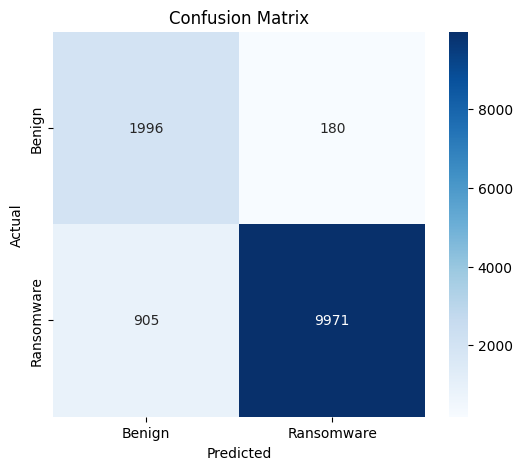

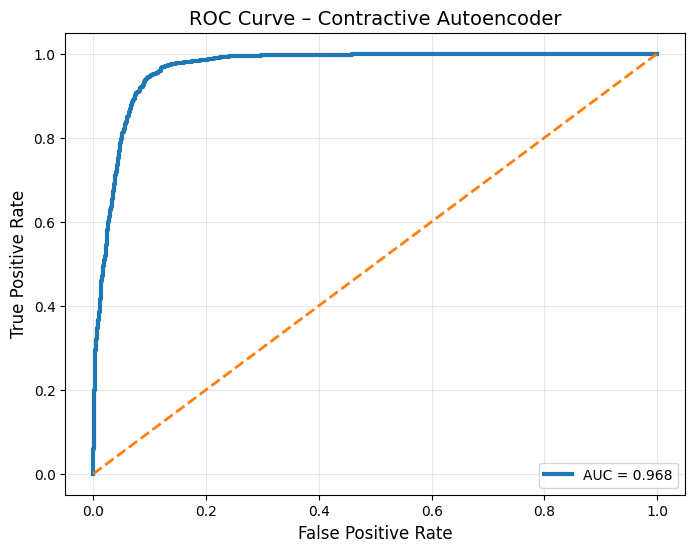

In [ ]:
# ============================================================
# Cell 10: Final Ransomware Detection Evaluation with Plots
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n" + "="*60)
print("FINAL RANSOMWARE DETECTION RESULTS")
print("="*60)

# Compute reconstruction errors using trained ContractiveAutoencoder instance
# Replace 'cae' with the name of your trained autoencoder instance
reconstruction_errors = cae.get_reconstruction_error(X_test)  # fixed

# Final chosen threshold (ROC + FPR constraint)
FINAL_THRESHOLD = 0.600
FINAL_THRESHOLD = np.log1p(FINAL_THRESHOLD)  # Apply same transformation as before

# Predictions
y_pred = (reconstruction_errors > FINAL_THRESHOLD).astype(int)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Metrics
accuracy = accuracy_score(y_test, y_pred)
recall = tp / (tp + fn)
fpr = fp / (fp + tn)

print(f"""
Threshold Used: {FINAL_THRESHOLD}

Confusion Matrix:
  TN (Benign → Benign): {tn}
  FP (Benign → Ransomware): {fp}
  FN (Ransomware → Benign): {fn}
  TP (Ransomware → Ransomware): {tp}

Performance:
  Accuracy: {accuracy*100:.2f}%
  Recall (TPR): {recall*100:.2f}%
  False Positive Rate (FPR): {fpr*100:.2f}%
""")

print("Detailed Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=["Benign", "Ransomware"]))


# -------------------- Plot Confusion Matrix --------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Benign","Ransomware"], yticklabels=["Benign","Ransomware"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# -------------------- Plot ROC Curve --------------------
# Get ROC curve values
fpr_values, tpr_values, thresholds = roc_curve(y_test, reconstruction_errors)
roc_auc = auc(fpr_values, tpr_values)

plt.figure(figsize=(8,6))
plt.plot(
    fpr_values,
    tpr_values,
    linewidth=3,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1], [0,1], linestyle='--', linewidth=2)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve – Contractive Autoencoder", fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


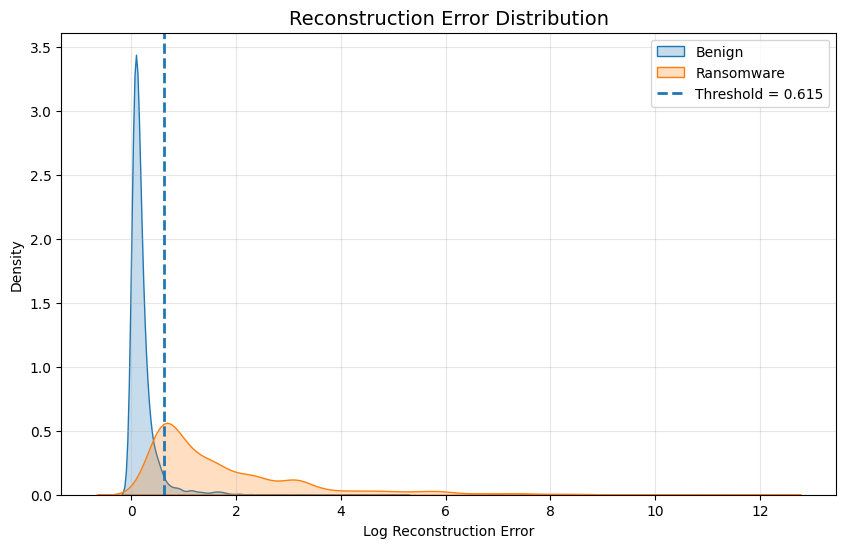

In [ ]:
# Separate errors by class
errors_benign = reconstruction_errors[y_test == 0]
errors_ransom = reconstruction_errors[y_test == 1]

plt.figure(figsize=(10,6))

sns.kdeplot(errors_benign, label="Benign", fill=True)
sns.kdeplot(errors_ransom, label="Ransomware", fill=True)

plt.axvline(FINAL_THRESHOLD, linestyle='--', linewidth=2,
            label=f"Threshold = {FINAL_THRESHOLD:.3f}")

plt.title("Reconstruction Error Distribution", fontsize=14)
plt.xlabel("Log Reconstruction Error")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


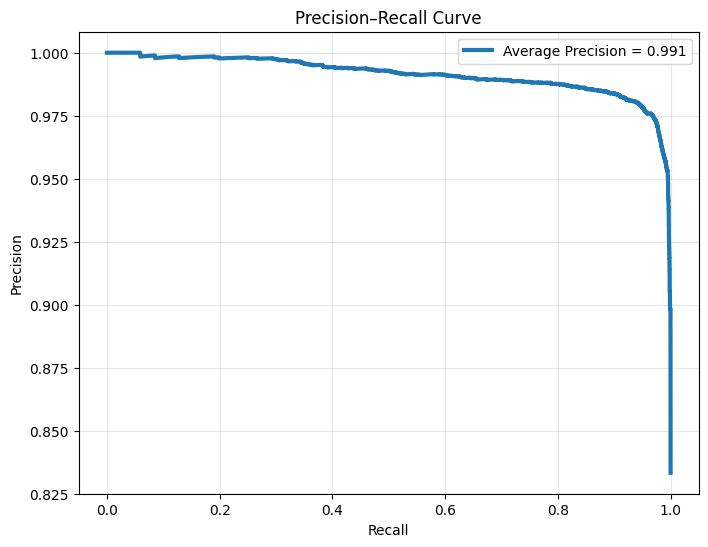

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, reconstruction_errors)
ap = average_precision_score(y_test, reconstruction_errors)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, linewidth=3,
         label=f"Average Precision = {ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


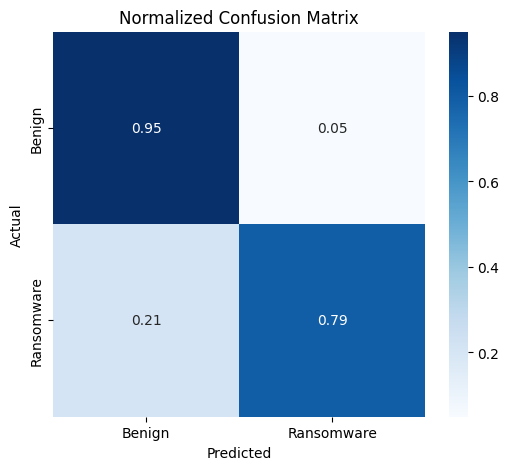

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["Benign", "Ransomware"],
    yticklabels=["Benign", "Ransomware"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix")
plt.show()


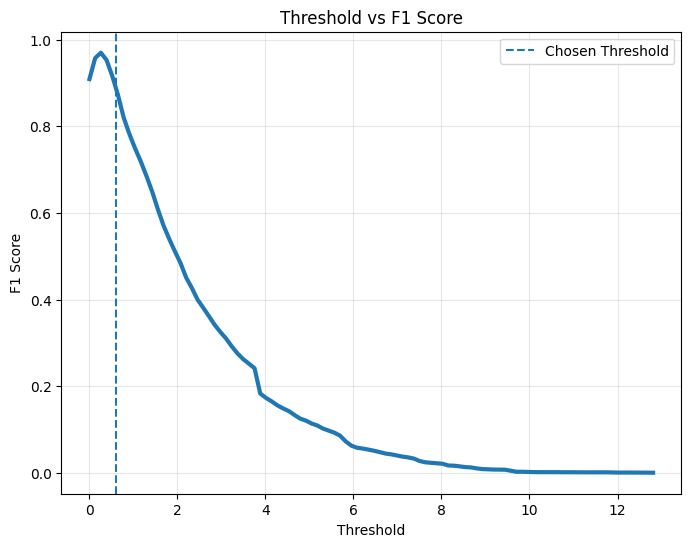

In [ ]:
from sklearn.metrics import f1_score

thresholds = np.linspace(
    reconstruction_errors.min(),
    reconstruction_errors.max(),
    100
)

f1_scores = []

for t in thresholds:
    preds = (reconstruction_errors > t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

plt.figure(figsize=(8,6))
plt.plot(thresholds, f1_scores, linewidth=3)
plt.axvline(FINAL_THRESHOLD, linestyle='--', label="Chosen Threshold")

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1 Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
